In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import components.broadcast_components.WZ_models.wz_quant_RNN
from components.broadcast_components.WZ_models.wz_quant_RNN import PL_EncoderDecoder_RNN
import components.broadcast_components.WZ_models.WZQuantizerWithDataPrep
import components.broadcast_components.WZ_models.WZ_quantizer
import utilities
import importlib
import random

# ----------------------------------------------------------------
torch.set_float32_matmul_precision('medium')
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
import warnings
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX` has been removed")
warnings.filterwarnings("ignore", message="You defined a `validation_step` but have no `val_dataloader`")
warnings.filterwarnings("ignore", message="Consider setting `persistent_workers=True` in 'train_dataloader'")
warnings.filterwarnings("ignore", message="The 'val_dataloader' does not have")

TypeError: expected string or bytes-like object, got 'NoneType'

In [6]:
from typing import OrderedDict
from components.broadcast_components.WZ_models.WZQuantizerWithDataPrep import _get_vec_slices, get_normalization_factor
from components.broadcast_components.broadcasting_process.ServerTrainingPerRoundProtocol import dict_to_array
import gzip
import pickle

# *********
# path_to_file = f'../exp_data/save_grads_per_round/grad_round_{0}_worker_{0}.pkl.gz'
# with gzip.open(path_to_file, 'rb') as f:
#     y, shape_dict = dict_to_array(pickle.load(f))
# *********
# temp=torch.load(f'../../data/resnet18_svhn.pth', map_location='cpu')
# temp= OrderedDict({k:v.cpu() for k,v in temp.items() if 'num_batches' not in k})
# y, shape_dict = dict_to_array(temp)
# *********

# vec_slices = _get_vec_slices(shape_dict)
# norm_factors = [get_normalization_factor(y[v_slc]) for v_slc in vec_slices]
# for i, temp in enumerate(vec_slices):
#     y[temp] /= norm_factors[i]

# y+=np.random.normal(0, np.sqrt(1e-8), len(y), ).astype(np.float32)
# side_info_data = []
# side_info_variance, noise_variance = utilities.get_data_var(y, side_info_data)
# ***************************************

temp = np.random.normal(0, np.sqrt(1), 10_000_000, ).astype(np.float32)
y = temp + np.random.normal(0, np.sqrt(0.01), 10_000_000, ).astype(np.float32)
side_info_data = [temp.copy()]
# ***************************************

# temp = np.random.random(10_000_000, ).astype(np.float32)*2-1
# y = temp + (np.random.random(10_000_000, ).astype(np.float32)*2-1)*0.25
# side_info_data = [temp.copy()]

near zero vales:0.80%


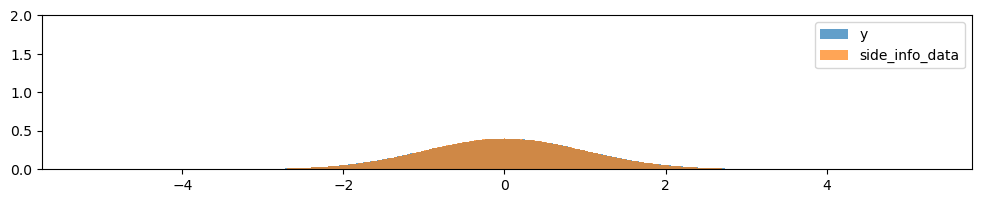

In [3]:
plt.figure(figsize=(12, 2))
plt.hist(y, alpha=0.7, bins=500, density=True, label='y')
if len(side_info_data):
    plt.hist(side_info_data[0], bins=500, alpha=0.7, density=True, label='side_info_data')
plt.ylim(0, 2)
print(f'near zero vales:{sum(np.abs(y)<0.01)/len(y)*100:.2f}%')
plt.legend()
plt.show()

In [5]:
importlib.reload(components.broadcast_components.WZ_models.WZQuantizerWithDataPrep)
from components.broadcast_components.WZ_models.WZQuantizerWithDataPrep import QuantizerWithDataPrep
importlib.reload(components.broadcast_components.WZ_models.WZ_quantizer)
from components.broadcast_components.WZ_models.WZ_quantizer import WZQuantizer

random.seed(101);torch.manual_seed(101);np.random.seed(101)

# ---------------------
wz_model = PL_EncoderDecoder_RNN(inp_dim=1, side_info_size=0, num_planes=1, bins_per_plane=8, tau=1.5, tau_rate=10,
                                 reconst_ld=400, lr=1e-3, marginal=True).to(torch.float32)

# ---------------------
# wz_model.load_state_dict(torch.load(r'..\..\data\basicRNN_2plane_4bins_state.pt', map_location='cpu'),strict=False)
# wz_model.load_state_dict(torch.load(r'..\..\data\basicRNN_global_correction.pt', map_location='cpu'),strict=False)

# ---------------------
wz_quantizer = WZQuantizer(wz_model, train_sample_size=200_000, count_side_info_data=1, enable_progress_bar=True)
# wz_quantizer = QuantizerWithDataPrep(wz_model, train_sample_size=200_000, vec_slices=[],
#                         count_side_info_data=0, enable_progress_bar=True, outlier_threshold=1.6)

# ---------------------
wz_quantizer.train_model(y, side_info_data, epoch=50, batch_size=10_000)

# ---------------------
# torch.save(wz_model.state_dict(), r'..\..\data\basicRNN_2plane_4bins_state.pt')
# torch.save(wz_model.state_dict(), r'..\..\data\basicRNN_global_correction.pt')

NameError: name 'importlib' is not defined

In [68]:
# temp1 = wz_quantizer.encoding_process(y)
# recons = wz_quantizer.decoding_process(temp1[0], side_info_data, temp1[1])

# ----------------
wz_model = PL_EncoderDecoder_RNN(inp_dim=1, side_info_size=0, num_planes=1, bins_per_plane=8, tau=1.5, tau_rate=10,
                                 reconst_ld=400, lr=1e-3, marginal=True).to(torch.float32)
wz_model.load_state_dict(torch.load(r'..\..\data\basicRNN_global_correction.pt', map_location='cpu'))
wz_quantizer = QuantizerWithDataPrep(wz_model, train_sample_size=200_000, vec_slices=[],
                        count_side_info_data=0, enable_progress_bar=True, outlier_threshold=1.3)
temp2 = wz_quantizer.encoding_process(y-recons)
recons2 = wz_quantizer.decoding_process(temp2[0], side_info_data, temp2[1])

(0.0, 200.0)

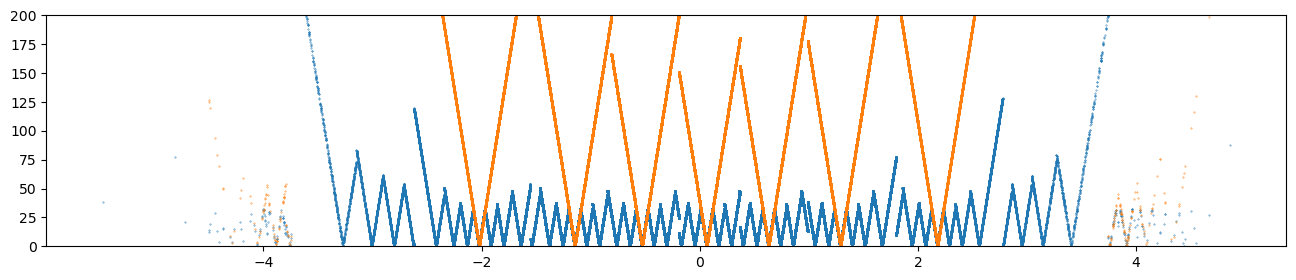

In [69]:
temp=np.argsort(y[:1_000_000])
plt.figure(figsize=(16, 3))
plt.scatter(y[temp], np.abs(y[temp]-(recons[temp]+recons2[temp]))/np.mean(y[temp]), s=0.1)
plt.scatter(y[temp], np.abs(y[temp]-recons[temp])/np.mean(y[temp]), s=0.1)
plt.ylim(0,200)

In [33]:
for i in [temp1[0][0], temp1[0][1], temp2[0][0]]:
    temp = torch.unique(i, return_counts=True)[1]/len(i)
    print(np.sum([-t*torch.log2(t) for t in temp]))

3.0446548
2.8168664
3.0481644


In [4]:
# importlib.reload(components.broadcast_components.WZ_models.WZ_quantizer)
from components.broadcast_components.WZ_models.WZ_quantizer import plot_bins

side_info_data = []
plot_bins(wz_quantizer, y, side_info_data, step_count=50_000)

TypeError: expected string or bytes-like object, got 'NoneType'

In [23]:
importlib.reload(components.broadcast_components.WZ_models.wz_quant_RNN)
importlib.reload(utilities)
mse, mspe, real_bit_rate, prior_bit_rate, softcodes_bit_rate = utilities.get_metrics(y, side_info_data, wz_quantizer, )
f'{mse=:0.5f}, {mspe=:0.3f}, {real_bit_rate=:0.3f}, {prior_bit_rate=:0.3f}, {softcodes_bit_rate=:0.3f}'

D:\User\App Files\Projects\VUB-ACS-25_Thesis\components\broadcast_components\WZ_models\WZ_quantizer.py:47: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4416.)
  side_info_array = torch.tensor(np.array(side_info_data_list), dtype=torch.float32).T


'mse=0.00058, mspe=0.688, real_bit_rate=3.571, prior_bit_rate=3.163, softcodes_bit_rate=0.056'

In [28]:
(np.sum(y>1.3)+ np.sum(y<-1.3))/len(y)*100

np.float64(0.7841334930952002)

In [24]:
wz_quantizer = WZQuantizer(wz_model, train_sample_size=200_000, count_side_info_data=0, enable_progress_bar=True)
mse, mspe, real_bit_rate, prior_bit_rate, softcodes_bit_rate = utilities.get_metrics(y, side_info_data, wz_quantizer, )
f'{mse=:0.5f}, {mspe=:0.3f}, {real_bit_rate=:0.3f}, {prior_bit_rate=:0.3f}, {softcodes_bit_rate=:0.3f}'

'mse=0.00278, mspe=3.316, real_bit_rate=3.609, prior_bit_rate=3.232, softcodes_bit_rate=0.054'

AssertionError: 

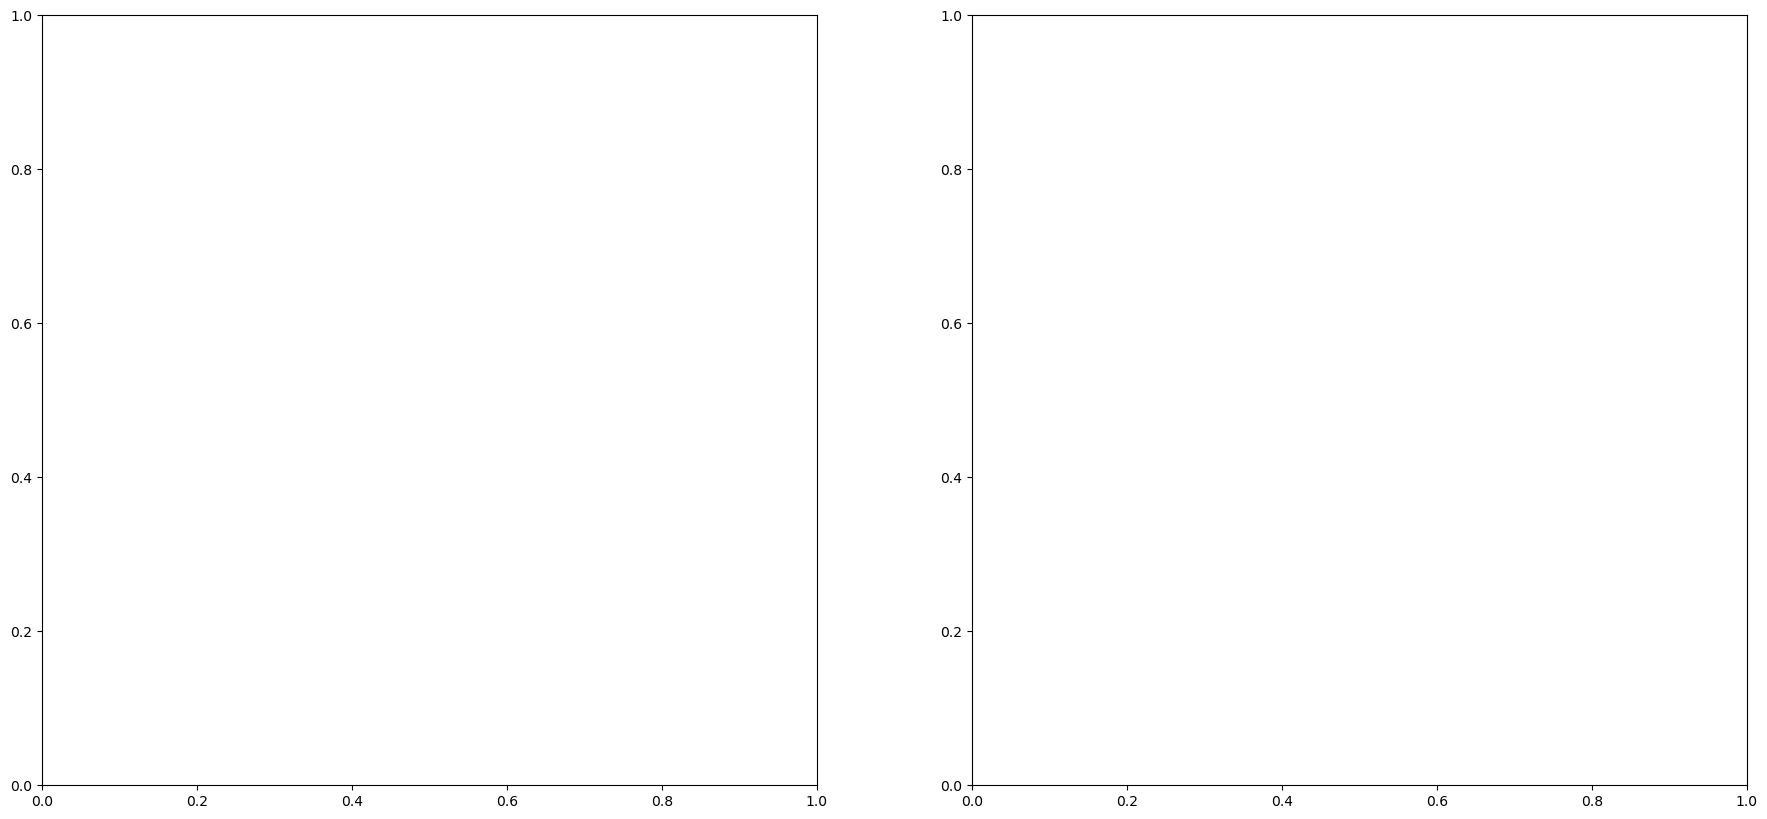

In [25]:
fig, axes = plt.subplots(1,2, figsize=(22, 10))
for i, ax in enumerate(axes):
    bound_x_y = utilities.bound_lines(y, side_info_variance+1e-8, noise_variance, mape_flag=(i==1))
    ax.plot(bound_x_y[0], bound_x_y[1], linewidth=1, label='WZ bound')
    ax.plot(bound_x_y[0], bound_x_y[1]+bound_x_y[2], linewidth=1, linestyle=':', label='Lattice error bound')

    ax.scatter(real_bit_rate, 10 * np.log10(mse if i == 0 else mspe), label='real_bit_rate', s=100, marker='x')
    ax.scatter(prior_bit_rate, 10 * np.log10(mse if i == 0 else mspe), label='prior_bit_rate', s=100, marker='x')

    ax.set_xlabel('Bit Rate (bpp)')
    ax.set_ylabel('Distortion (dB)')
    ax.grid(True)
    ax.legend()
axes[0].set_title('MSE')
axes[1].set_title('mspe')
plt.show()